In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
from pathlib import Path
from scipy.ndimage import uniform_filter1d

In [2]:
BASE = Path('../runs/poster')
runs = {
    'M = 16':  BASE / 'm16'  / 'train_log.csv',
    'M = 64':  BASE / 'm64'  / 'train_log.csv',
    'M = 256': BASE / 'm256' / 'train_log.csv',
}
dfs = {label: pd.read_csv(path) for label, path in runs.items()}

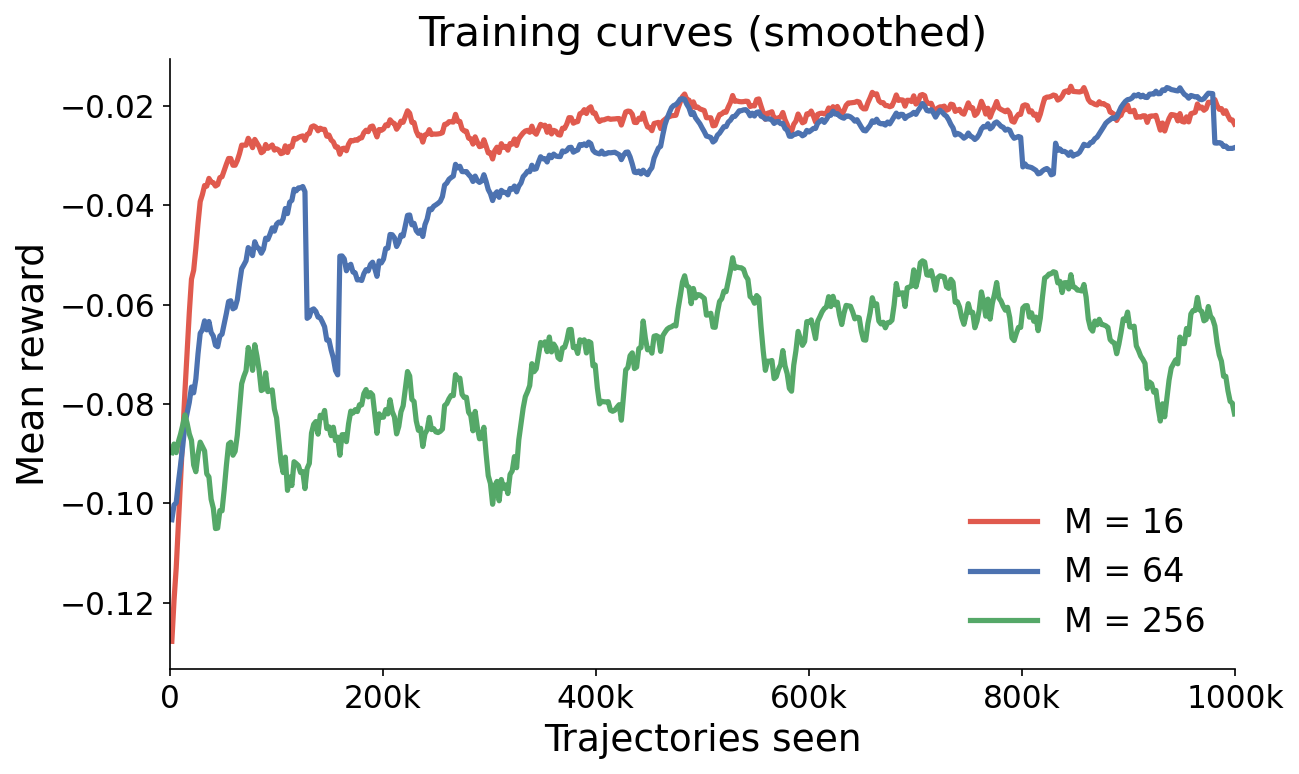

Saved to ../outputs/poster_figures/


In [3]:
# ── Poster style ────────────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'sans-serif',
    'font.size':         18,
    'axes.titlesize':    20,
    'axes.labelsize':    18,
    'xtick.labelsize':   15,
    'ytick.labelsize':   15,
    'legend.fontsize':   16,
    'lines.linewidth':   2.5,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'figure.dpi':        150,
})

COLORS     = ['#E05A4E', '#4C72B0', '#55A868']   # red, blue, green
SMOOTH     = 15           # uniform-filter window (steps)
TOTAL_TRAJ = 1_000_000   # x-axis upper limit (trajectories seen)

OUT = Path('../outputs/poster_figures')
OUT.mkdir(parents=True, exist_ok=True)


def smooth(x, w=SMOOTH):
    return uniform_filter1d(x, size=w, mode='nearest')


fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(dfs.items(), COLORS):
    # traj column = step * batch_size, already in the log
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)
    # ax.fill_between(traj, s_mean - s_std, s_mean + s_std,
    #                 color=color, alpha=0.18, linewidth=0)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Training curves (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_training_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_training_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')

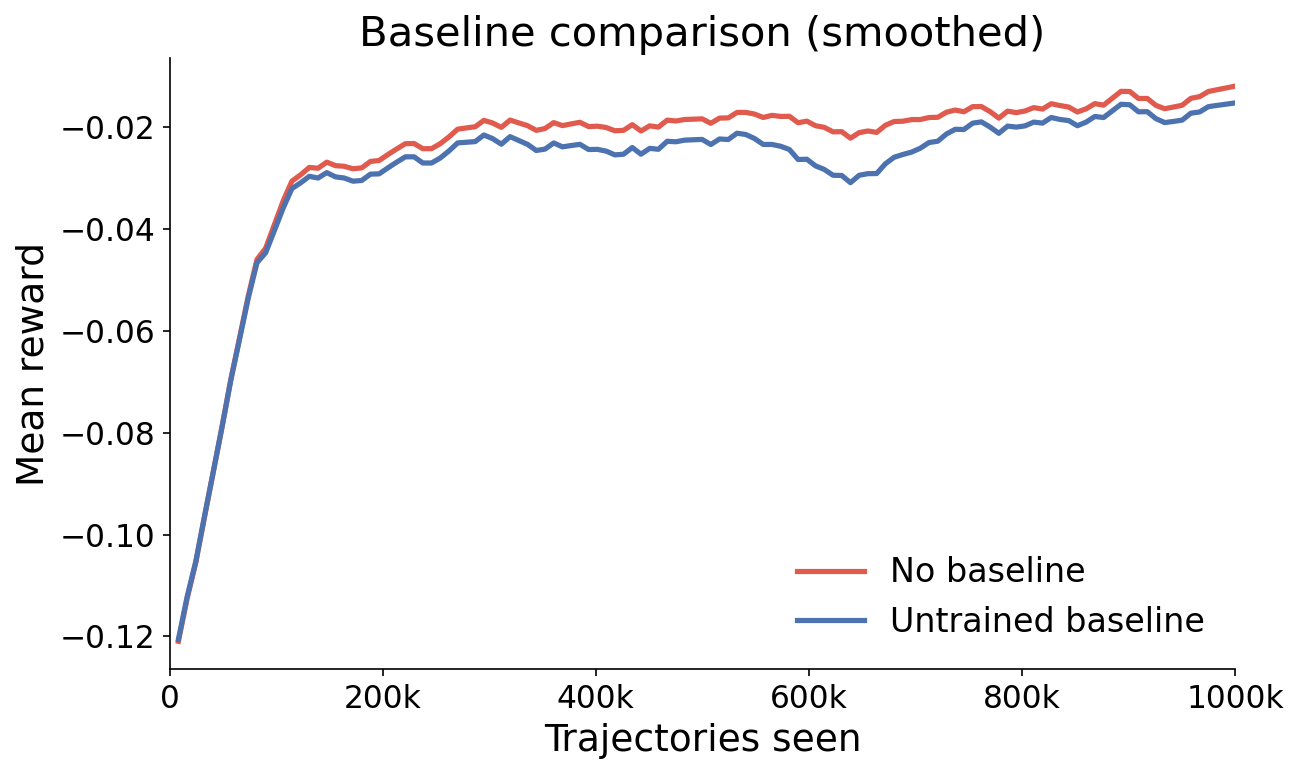

Saved to ../outputs/poster_figures/


In [4]:
baseline_runs = {
    'No baseline':        BASE / 'baseline_none'       / 'train_log.csv',
    'Untrained baseline': BASE / 'baseline_randominit' / 'train_log.csv',
}
baseline_dfs = {label: pd.read_csv(path) for label, path in baseline_runs.items()}

fig, ax = plt.subplots(figsize=(9, 5.5))

for (label, df), color in zip(baseline_dfs.items(), COLORS):
    df = df[df['traj'] <= TOTAL_TRAJ]
    traj   = df['traj'].values
    r_mean = df['reward_mean'].values
    r_std  = df['reward_std'].values

    s_mean = smooth(r_mean)
    s_std  = smooth(r_std)

    ax.plot(traj, s_mean, color=color, label=label)

ax.set_xlabel('Trajectories seen')
ax.set_ylabel('Mean reward')
ax.set_title('Baseline comparison (smoothed)')
ax.set_xlim(0, TOTAL_TRAJ)
ax.legend(frameon=False)
ax.xaxis.set_major_formatter(ticker.FuncFormatter(
    lambda x, _: f'{int(x/1000)}k' if x > 0 else '0'
))

fig.tight_layout()
fig.savefig(OUT / 'poster_baseline_curves.pdf', bbox_inches='tight')
fig.savefig(OUT / 'poster_baseline_curves.png', bbox_inches='tight', dpi=300)
plt.show()
print(f'Saved to {OUT}/')